Sinusoidal PE output: torch.Size([2, 50, 64])
Learned PE output:    torch.Size([2, 50, 64])
RoPE output:          torch.Size([2, 8, 50, 8])


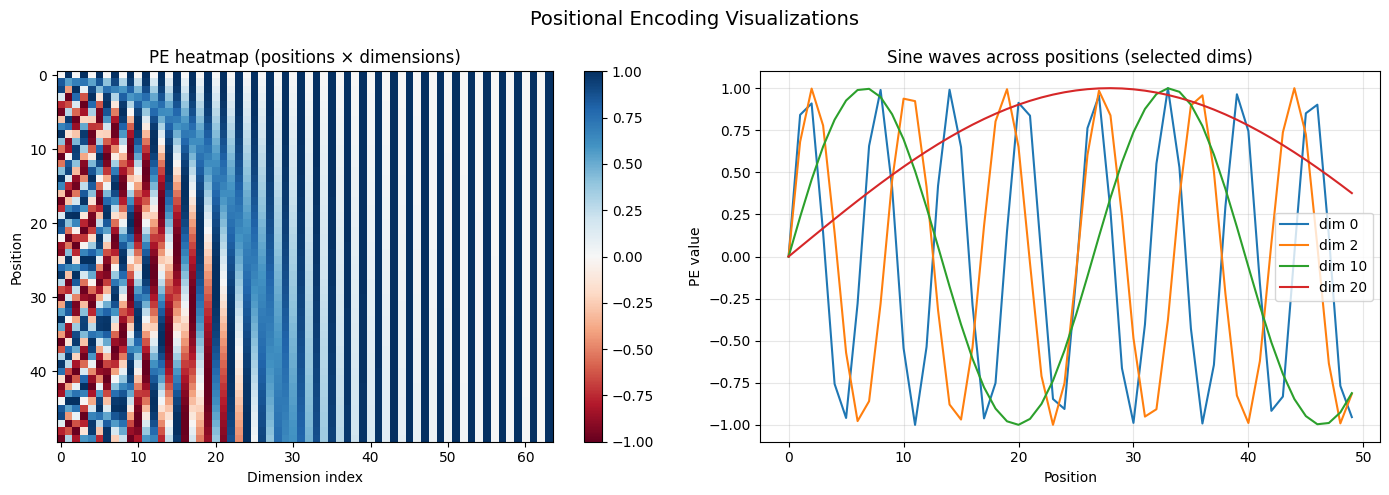


Mini-Transformer output: torch.Size([2, 20, 64])
Total parameters: 49,984


In [1]:
# ============================================================
# Positional Encoding — from scratch in PyTorch
# Colab-ready, no extra installs needed
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# ─────────────────────────────────────────
# 1. Sinusoidal Positional Encoding (Classic)
# ─────────────────────────────────────────
class SinusoidalPositionalEncoding(nn.Module):
    """
    Original Transformer PE (Vaswani et al., 2017).
    Fixed (not learned) — computed from sine/cosine functions.
    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
    """
    def __init__(self, d_model: int, max_seq_len: int = 5000, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Build the PE matrix: shape (max_seq_len, d_model)
        pe = torch.zeros(max_seq_len, d_model)

        # positions: column vector [0, 1, 2, ..., max_seq_len-1]
        position = torch.arange(0, max_seq_len).unsqueeze(1).float()

        # Dimension indices for even positions: [0, 2, 4, ..., d_model-2]
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() *
            (-math.log(10000.0) / d_model)
        )
        # This is equivalent to: 1 / 10000^(2i/d_model)
        # Using exp(log) for numerical stability

        pe[:, 0::2] = torch.sin(position * div_term)  # even dims → sine
        pe[:, 1::2] = torch.cos(position * div_term)  # odd dims  → cosine

        # Add batch dimension: (1, max_seq_len, d_model) so it broadcasts
        pe = pe.unsqueeze(0)

        # Register as buffer (not a parameter — not updated by optimizer)
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (batch_size, seq_len, d_model)
        Returns: x + positional encoding, same shape
        """
        # x[:, :x.size(1)] slices PE to match actual sequence length
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


# ─────────────────────────────────────────
# 2. Learned Positional Encoding
# (used in BERT, GPT-2, etc.)
# ─────────────────────────────────────────
class LearnedPositionalEncoding(nn.Module):
    """
    Simple nn.Embedding where each position index maps to a learned vector.
    Advantages: more flexible, adapts to data.
    Disadvantages: can't generalize beyond max_seq_len seen at training.
    """
    def __init__(self, d_model: int, max_seq_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        self.embedding = nn.Embedding(max_seq_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (batch_size, seq_len, d_model)
        """
        seq_len = x.size(1)
        # Create position indices: [0, 1, 2, ..., seq_len-1]
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)  # (1, seq_len)
        pos_emb = self.embedding(positions)  # (1, seq_len, d_model)
        return self.dropout(x + pos_emb)


# ─────────────────────────────────────────
# 3. RoPE — Rotary Positional Encoding
# (used in LLaMA, GPT-NeoX, modern LLMs)
# ─────────────────────────────────────────
def apply_rotary_embedding(x: torch.Tensor, seq_len: int) -> torch.Tensor:
    """
    Rotary PE (Su et al., 2021 — RoFormer).
    Instead of adding position to embeddings, it ROTATES query/key vectors.
    Key property: the dot product Q·K captures relative position automatically.

    x: (batch, heads, seq_len, head_dim)
    """
    d = x.shape[-1]
    # Compute rotation angles for each dimension pair
    theta = 1.0 / (10000 ** (torch.arange(0, d, 2, device=x.device).float() / d))
    positions = torch.arange(seq_len, device=x.device).float()
    angles = torch.outer(positions, theta)        # (seq_len, d/2)
    cos_a = angles.cos()[None, None, :, :]         # broadcast over batch, heads
    sin_a = angles.sin()[None, None, :, :]

    # Split into pairs and apply 2D rotation to each pair
    x1 = x[..., 0::2]  # even dims
    x2 = x[..., 1::2]  # odd dims
    rotated = torch.stack([
        x1 * cos_a - x2 * sin_a,
        x1 * sin_a + x2 * cos_a
    ], dim=-1)
    return rotated.flatten(-2)


# ─────────────────────────────────────────
# 4. Side-by-side Comparison
# ─────────────────────────────────────────
d_model  = 64
seq_len  = 50
batch    = 2

x = torch.randn(batch, seq_len, d_model)

# Sinusoidal
sin_pe = SinusoidalPositionalEncoding(d_model, dropout=0.0)
out_sin = sin_pe(x)
print(f"Sinusoidal PE output: {out_sin.shape}")  # (2, 50, 64)

# Learned
learn_pe = LearnedPositionalEncoding(d_model, dropout=0.0)
out_learn = learn_pe(x)
print(f"Learned PE output:    {out_learn.shape}")  # (2, 50, 64)

# RoPE (applied to Q/K vectors inside attention — different interface)
x_qk = torch.randn(batch, 8, seq_len, d_model // 8)  # (batch, heads, seq, head_dim)
out_rope = apply_rotary_embedding(x_qk, seq_len)
print(f"RoPE output:          {out_rope.shape}")     # (2, 8, 50, 8)


# ─────────────────────────────────────────
# 5. Visualize the Sinusoidal PE Matrix
# ─────────────────────────────────────────
def make_pe_matrix(d_model, max_seq_len):
    pe = np.zeros((max_seq_len, d_model))
    for pos in range(max_seq_len):
        for i in range(0, d_model, 2):
            pe[pos, i]     = np.sin(pos / (10000 ** (i / d_model)))
            if i + 1 < d_model:
                pe[pos, i+1] = np.cos(pos / (10000 ** (i / d_model)))
    return pe

pe_matrix = make_pe_matrix(d_model=64, max_seq_len=50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Positional Encoding Visualizations", fontsize=14)

# Heatmap
axes[0].imshow(pe_matrix, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
axes[0].set_title("PE heatmap (positions × dimensions)")
axes[0].set_xlabel("Dimension index")
axes[0].set_ylabel("Position")
plt.colorbar(axes[0].images[0], ax=axes[0])

# Sine waves for first 4 dimensions at various frequencies
dims_to_plot = [0, 2, 10, 20]
for d in dims_to_plot:
    axes[1].plot(pe_matrix[:, d], label=f"dim {d}")
axes[1].set_title("Sine waves across positions (selected dims)")
axes[1].set_xlabel("Position")
axes[1].set_ylabel("PE value")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ─────────────────────────────────────────
# 6. Full Mini-Transformer Using PE
# ─────────────────────────────────────────
class MiniTransformerBlock(nn.Module):
    """A single transformer block with PE included."""
    def __init__(self, d_model=64, num_heads=4, ff_dim=256, max_seq_len=512):
        super().__init__()
        self.pe        = SinusoidalPositionalEncoding(d_model, max_seq_len)
        self.attn      = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.norm1     = nn.LayerNorm(d_model)
        self.norm2     = nn.LayerNorm(d_model)
        self.ff        = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )

    def forward(self, x):
        x = self.pe(x)                              # 1. Add positional info
        attn_out, _ = self.attn(x, x, x)           # 2. Self-attention
        x = self.norm1(x + attn_out)               # 3. Residual + LayerNorm
        ff_out = self.ff(x)                        # 4. Feed-forward
        x = self.norm2(x + ff_out)                 # 5. Residual + LayerNorm
        return x

# Test it
model = MiniTransformerBlock(d_model=64, num_heads=4)
x = torch.randn(2, 20, 64)  # batch=2, seq=20, d_model=64
out = model(x)
print(f"\nMini-Transformer output: {out.shape}")    # (2, 20, 64)

params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {params:,}")